# Part 3 — Churn Prediction Model & Model Card

**Capstone: D2C Customer Churn Intelligence & Retention API**

**Snapshot Date:** `2025-09-30`  
**Target:** `churn_next_60d` — 1 if no purchase in next 60 days, else 0

---

## 0. Setup & Imports

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)
import lightgbm as lgb
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_DIR   = 'data/'
MODEL_PATH = 'model.pkl'
METRICS_PATH = 'metrics.json'
RANDOM_SEED = 42

## 1. Load Data

In [56]:
rfm    = pd.read_csv(f'{DATA_DIR}rfm_modeling_snapshot.csv')
labels = pd.read_csv(f'{DATA_DIR}churn_labels.csv')

# Merge on customer_id — use rfm_modeling_snapshot as the feature table
data = rfm.merge(labels[['customer_id', 'split']], on='customer_id', how='left', suffixes=('', '_lbl'))

# Use the split column from churn_labels if not already in rfm
if 'split_lbl' in data.columns:
    data['split'] = data['split_lbl']
    data.drop(columns=['split_lbl'], inplace=True)

print(f'Total rows: {len(data)}')
print(data['split'].value_counts())
print(data['churn_next_60d'].value_counts())

Total rows: 2400
split
train         1728
validation     336
test           336
Name: count, dtype: int64
churn_next_60d
0    1273
1    1127
Name: count, dtype: int64


## 2. Feature Preparation

In [57]:
# Columns to exclude (target, ID, date, split)
EXCLUDE = ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']

TARGET = 'churn_next_60d'

# Identify feature types
all_features = [c for c in data.columns if c not in EXCLUDE]

cat_features = [
    'city_tier', 'age_group', 'acquisition_channel',
    'loyalty_tier', 'preferred_category', 'marketing_consent'
]
num_features = [c for c in all_features if c not in cat_features]

print(f'Numeric features ({len(num_features)}): {num_features}')
print(f'Categorical features ({len(cat_features)}): {cat_features}')

# Verify no post-snapshot leakage
assert 'order_date' not in all_features, 'LEAKAGE: raw order_date found in features!'
print('\nLeakage check passed — no raw order dates in feature set.')

Numeric features (19): ['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']
Categorical features (6): ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']

Leakage check passed — no raw order dates in feature set.


In [58]:
# Train / Val / Test splits
train_data = data[data['split'] == 'train'].copy()
val_data   = data[data['split'] == 'validation'].copy()
test_data  = data[data['split'] == 'test'].copy()

X_train = train_data[all_features]
y_train = train_data[TARGET]

X_val   = val_data[all_features]
y_val   = val_data[TARGET]

X_test  = test_data[all_features]
y_test  = test_data[TARGET]

print(f'Train: {len(X_train)} rows, churn rate: {y_train.mean():.3f}')
print(f'Val:   {len(X_val)} rows, churn rate: {y_val.mean():.3f}')
print(f'Test:  {len(X_test)} rows, churn rate: {y_test.mean():.3f}')

Train: 1728 rows, churn rate: 0.470
Val:   336 rows, churn rate: 0.438
Test:  336 rows, churn rate: 0.500


## 3. Preprocessing Pipeline

In [59]:
# Numeric: impute with median, scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical: impute with constant ('missing'), ordinal encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

print('Preprocessor defined.')

Preprocessor defined.


## 4. Model 1 — Logistic Regression (Baseline)

In [60]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED))
])

lr_pipe.fit(X_train, y_train)

lr_val_proba = lr_pipe.predict_proba(X_val)[:, 1]
lr_val_auc   = roc_auc_score(y_val, lr_val_proba)
lr_val_ap    = average_precision_score(y_val, lr_val_proba)

print(f'Logistic Regression — Validation AUC-ROC: {lr_val_auc:.4f}')
print(f'Logistic Regression — Validation Avg Precision: {lr_val_ap:.4f}')

Logistic Regression — Validation AUC-ROC: 0.8847
Logistic Regression — Validation Avg Precision: 0.8690


## 5. Model 2 — LightGBM (Stronger Model)

In [61]:
lgbm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        verbose=-1
    ))
])

lgbm_pipe.fit(X_train, y_train)

lgbm_val_proba = lgbm_pipe.predict_proba(X_val)[:, 1]
lgbm_val_auc   = roc_auc_score(y_val, lgbm_val_proba)
lgbm_val_ap    = average_precision_score(y_val, lgbm_val_proba)

print(f'LightGBM — Validation AUC-ROC: {lgbm_val_auc:.4f}')
print(f'LightGBM — Validation Avg Precision: {lgbm_val_ap:.4f}')

LightGBM — Validation AUC-ROC: 0.8754
LightGBM — Validation Avg Precision: 0.8551


## 6. Model Comparison & ROC Curves

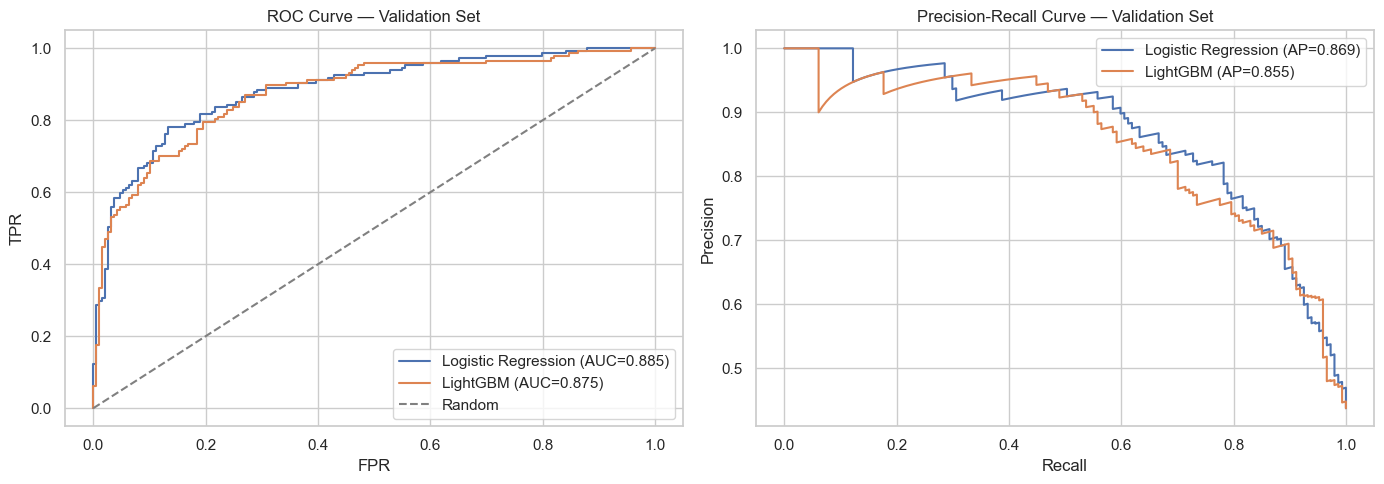

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
for name, proba in [('Logistic Regression', lr_val_proba), ('LightGBM', lgbm_val_proba)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[0].set_title('ROC Curve — Validation Set')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

# Precision-Recall Curve
for name, proba in [('Logistic Regression', lr_val_proba), ('LightGBM', lgbm_val_proba)]:
    prec, rec, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})')
axes[1].set_title('Precision-Recall Curve — Validation Set')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/chart_01_roc_pr_curves.png', dpi=100)
plt.show()

## 7. Decision Threshold Selection

**Business Context:**  
- A **False Negative** (missing a churner) means we lose a customer we could have saved — direct revenue loss.
- A **False Positive** (flagging a non-churner) means we spend retention budget on someone who would have stayed — budget waste, but no customer loss.

Since missing churners is more costly than wasting a small retention budget on loyal customers, we **prefer higher recall** at the cost of some precision. We target a threshold that achieves **recall ≥ 0.70** on the validation set.

Selected threshold: 0.5795
Precision at threshold: 0.7803
Recall at threshold:    0.7007


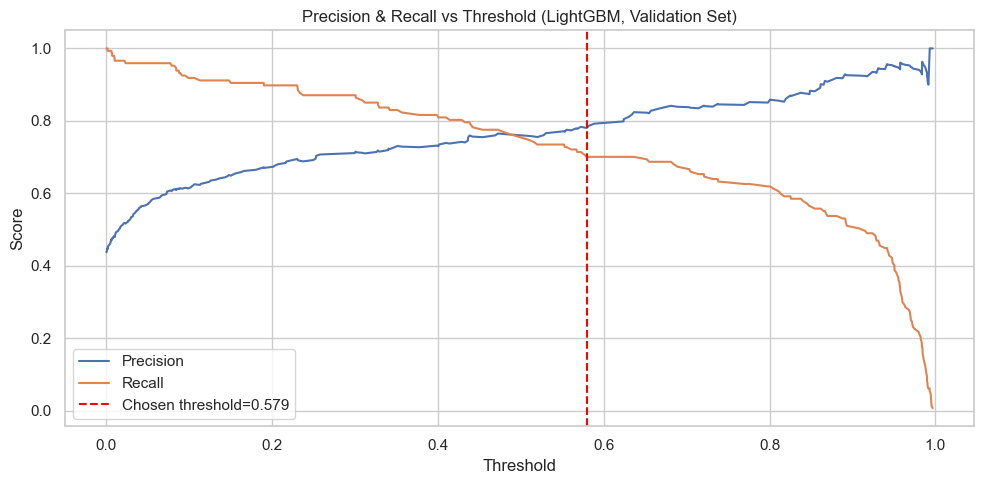

In [63]:
# Find threshold on LightGBM (our final model) for target recall
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, lgbm_val_proba)

TARGET_RECALL = 0.70

# Select threshold where recall is closest to TARGET_RECALL
idx = np.argmin(np.abs(rec_arr[:-1] - TARGET_RECALL))
THRESHOLD = thresh_arr[idx]
selected_prec   = prec_arr[idx]
selected_recall = rec_arr[idx]

print(f'Selected threshold: {THRESHOLD:.4f}')
print(f'Precision at threshold: {selected_prec:.4f}')
print(f'Recall at threshold:    {selected_recall:.4f}')

# Plot threshold selection
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_arr, prec_arr[:-1], label='Precision')
ax.plot(thresh_arr, rec_arr[:-1],  label='Recall')
ax.axvline(THRESHOLD, color='red', linestyle='--', label=f'Chosen threshold={THRESHOLD:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs Threshold (LightGBM, Validation Set)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/chart_02_threshold_selection.png', dpi=100)
plt.show()

## 8. Final Model Evaluation on Test Set

=== Test Set Evaluation ===
AUC-ROC:           0.8474
Average Precision: 0.8090
F1 Score:          0.7818
Precision:         0.7963
Recall:            0.7679

              precision    recall  f1-score   support

    Retained       0.78      0.80      0.79       168
     Churned       0.80      0.77      0.78       168

    accuracy                           0.79       336
   macro avg       0.79      0.79      0.79       336
weighted avg       0.79      0.79      0.79       336



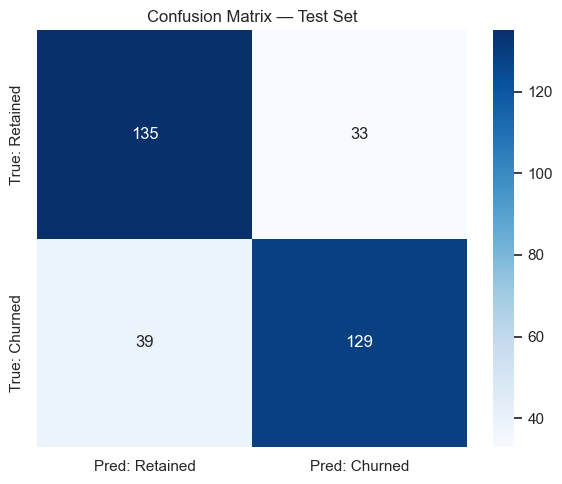

In [64]:
# Final predictions using LightGBM + chosen threshold
test_proba = lgbm_pipe.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= THRESHOLD).astype(int)

# Metrics
test_auc  = roc_auc_score(y_test, test_proba)
test_ap   = average_precision_score(y_test, test_proba)
test_f1   = f1_score(y_test, test_pred)
test_prec = precision_score(y_test, test_pred)
test_rec  = recall_score(y_test, test_pred)

print('=== Test Set Evaluation ===')
print(f'AUC-ROC:           {test_auc:.4f}')
print(f'Average Precision: {test_ap:.4f}')
print(f'F1 Score:          {test_f1:.4f}')
print(f'Precision:         {test_prec:.4f}')
print(f'Recall:            {test_rec:.4f}')
print()
print(classification_report(y_test, test_pred, target_names=['Retained', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Retained', 'Pred: Churned'],
            yticklabels=['True: Retained', 'True: Churned'], ax=ax)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('charts/chart_03_confusion_matrix.png', dpi=100)
plt.show()

## 9. Feature Importance & SHAP

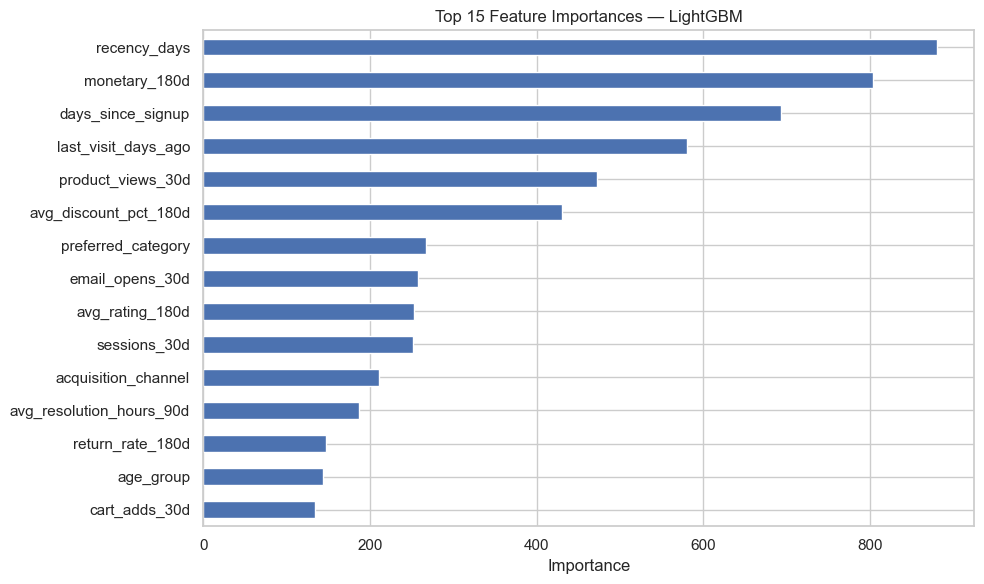

In [65]:
# LightGBM native feature importance
lgbm_model = lgbm_pipe.named_steps['classifier']
feature_names = num_features + cat_features

importances = pd.Series(lgbm_model.feature_importances_, index=feature_names)\
    .sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(15).plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importances — LightGBM')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('charts/chart_04_feature_importance.png', dpi=100)
plt.show()

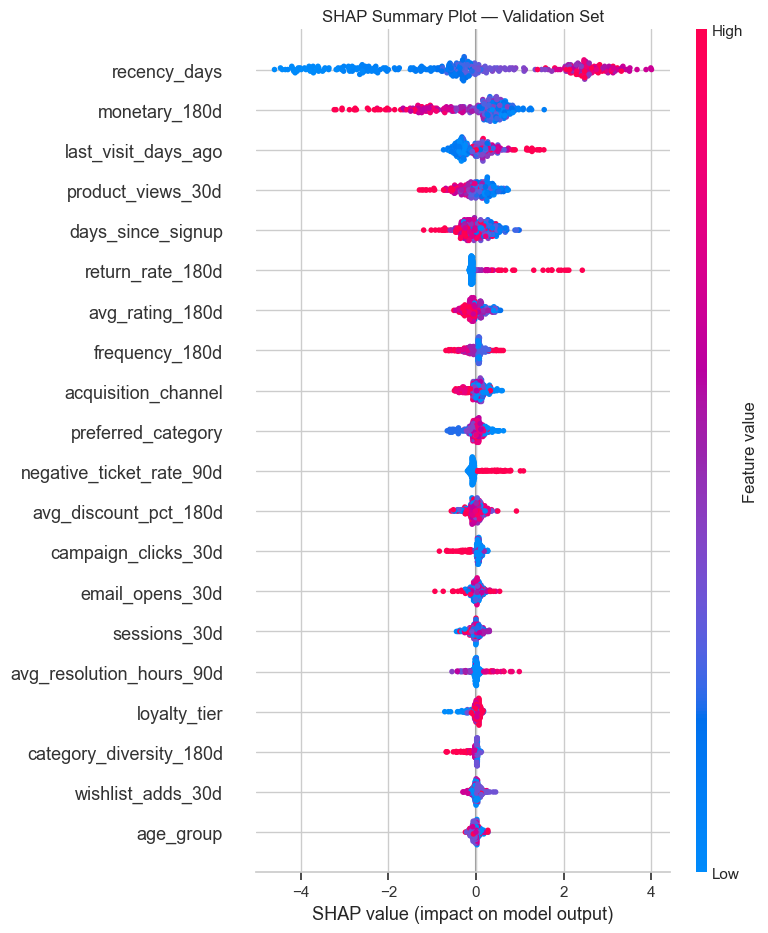

In [66]:
# SHAP values on validation set
X_val_transformed = lgbm_pipe.named_steps['preprocessor'].transform(X_val)
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_val_transformed)

# For binary classification, shap_values may be a list; take class 1
if isinstance(shap_values, list):
    shap_vals_plot = shap_values[1]
else:
    shap_vals_plot = shap_values

shap.summary_plot(
    shap_vals_plot,
    X_val_transformed,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Summary Plot — Validation Set')
plt.tight_layout()
plt.savefig('charts/chart_05_shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Error Analysis — False Positives & False Negatives

In [67]:
# Build error analysis dataframe
error_df = test_data[['customer_id'] + all_features + [TARGET]].copy()
error_df['churn_proba']  = test_proba
error_df['churn_pred']   = test_pred
error_df['error_type']   = 'Correct'

error_df.loc[(error_df[TARGET] == 0) & (error_df['churn_pred'] == 1), 'error_type'] = 'False Positive'
error_df.loc[(error_df[TARGET] == 1) & (error_df['churn_pred'] == 0), 'error_type'] = 'False Negative'

fp_df = error_df[error_df['error_type'] == 'False Positive'].sort_values('churn_proba', ascending=False)
fn_df = error_df[error_df['error_type'] == 'False Negative'].sort_values('churn_proba')

print(f'False Positives: {len(fp_df)}')
print(f'False Negatives: {len(fn_df)}')

print('\nTop 5 False Positives (predicted churn, actually retained):')
print(fp_df[['customer_id', 'churn_proba', 'recency_days', 'frequency_180d', 'monetary_180d', 'sessions_30d']].head(5).to_string(index=False))

print('\nTop 5 False Negatives (predicted retained, actually churned):')
print(fn_df[['customer_id', 'churn_proba', 'recency_days', 'frequency_180d', 'monetary_180d', 'sessions_30d']].head(5).to_string(index=False))

False Positives: 33
False Negatives: 39

Top 5 False Positives (predicted churn, actually retained):
customer_id  churn_proba  recency_days  frequency_180d  monetary_180d  sessions_30d
  CUST01246     0.995029           262               0           0.00             1
  CUST01370     0.995023           161               2        1246.04             2
  CUST00491     0.985505            97               1         540.89            10
  CUST00437     0.981705           151               1         729.22             0
  CUST01614     0.968640           103               2        1352.11             4

Top 5 False Negatives (predicted retained, actually churned):
customer_id  churn_proba  recency_days  frequency_180d  monetary_180d  sessions_30d
  CUST01990     0.005631            59               4        3877.77            11
  CUST00184     0.006686            14               3        2456.91             6
  CUST00596     0.033795            50               1         503.66           

## 11. Save Model & Metrics

In [68]:
# Save model
joblib.dump(lgbm_pipe, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

# Save metrics
metrics = {
    'model': 'LightGBM',
    'threshold': float(THRESHOLD),
    'validation': {
        'auc_roc': float(lgbm_val_auc),
        'avg_precision': float(lgbm_val_ap)
    },
    'test': {
        'auc_roc':        float(test_auc),
        'avg_precision':  float(test_ap),
        'f1_score':       float(test_f1),
        'precision':      float(test_prec),
        'recall':         float(test_rec)
    },
    'baseline_logistic_regression': {
        'validation_auc_roc':       float(lr_val_auc),
        'validation_avg_precision': float(lr_val_ap)
    }
}

with open(METRICS_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Metrics saved to {METRICS_PATH}')
print(json.dumps(metrics, indent=2))

Model saved to model.pkl
Metrics saved to metrics.json
{
  "model": "LightGBM",
  "threshold": 0.5794634556223018,
  "validation": {
    "auc_roc": 0.8753914264118345,
    "avg_precision": 0.8550612432959588
  },
  "test": {
    "auc_roc": 0.8473639455782312,
    "avg_precision": 0.8089977547783191,
    "f1_score": 0.7818181818181819,
    "precision": 0.7962962962962963,
    "recall": 0.7678571428571429
  },
  "baseline_logistic_regression": {
    "validation_auc_roc": 0.884677680596048,
    "validation_avg_precision": 0.869048155553733
  }
}


---
## ✅ Notebook Complete

Outputs:
- `model.pkl` — saved LightGBM pipeline
- `metrics.json` — evaluation metrics
- `chart_01` through `chart_05` — visualisations

See `error_analysis.md` for the full FP/FN case review and `model_card.md` for the model card.